In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("hf://datasets/cajcodes/political-bias/political_bias.csv")

In [3]:
print(df.shape)

df.head()
df.info()
df.describe(include="all")

(657, 2)
<class 'pandas.DataFrame'>
RangeIndex: 657 entries, 0 to 656
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    657 non-null    str  
 1   label   657 non-null    int64
dtypes: int64(1), str(1)
memory usage: 63.5 KB


,text,label
count,657,657.000000
unique,612,NaN
top,Moderate healthcare reforms should balance cos...,NaN
freq,3,NaN
mean,NaN,1.931507
std,NaN,1.135565
min,NaN,0.000000
25%,NaN,1.000000
50%,NaN,2.000000
75%,NaN,3.000000


In [5]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Dataset shape after removing duplicates: {df.shape}")

Duplicate rows: 0


In [6]:
print(df.isnull().sum())

text     0
label    0
dtype: int64


In [7]:
df.head()

,text,label
0,The government should reduce taxes significant...,0
1,Cutting welfare programs is necessary to encou...,0
2,A strong military is essential for national se...,0
3,Deregulation is crucial to promote free market...,0
4,Traditional family values should be upheld to ...,0


In [8]:
df.describe(include="all")

,text,label
count,615,615.000000
unique,612,NaN
top,Investing in mental health services is essenti...,NaN
freq,2,NaN
mean,NaN,1.926829
std,NaN,1.154024
min,NaN,0.000000
25%,NaN,1.000000
50%,NaN,2.000000
75%,NaN,3.000000


In [9]:
print(df["label"].value_counts().sort_index())

label
0     55
1    195
2    178
3    114
4     73
Name: count, dtype: int64


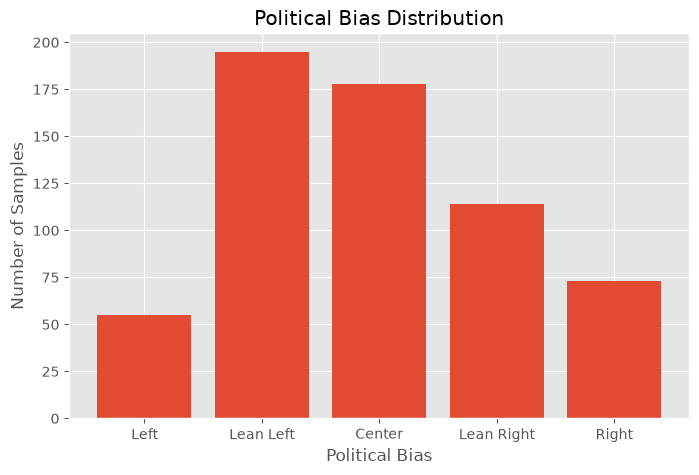

In [10]:
counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(counts.index, counts.values)

plt.xticks(
    [0,1,2,3,4],
    ["Left","Lean Left","Center","Lean Right","Right"]
)

plt.xlabel("Political Bias")
plt.ylabel("Number of Samples")
plt.title("Political Bias Distribution")

plt.show()

In [11]:
df["text_length"] = df["text"].apply(len)

In [12]:
df["text_length"].describe()

count    615.000000
mean      82.860163
std        8.713684
min       63.000000
25%       77.000000
50%       82.000000
75%       88.000000
max      124.000000
Name: text_length, dtype: float64

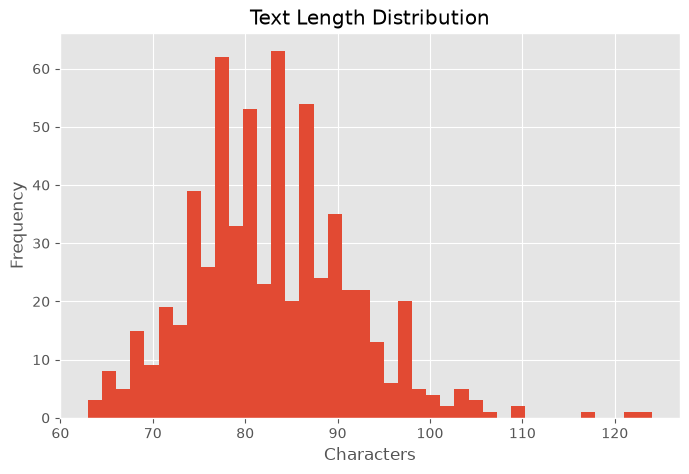

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df["text_length"], bins=40)

plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.title("Text Length Distribution")

plt.show()

In [14]:
print(df.loc[df["text_length"].idxmax(), "text"])

In a balanced view, both sides of the argument suggest that economic policies should promote growth while ensuring fairness.


In [15]:
print(df.loc[df["text_length"].idxmin(), "text"])

Governance should balance economic freedom with public welfare.


In [16]:
df.to_csv("../data/processed/processed_dataset.csv", index=False)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!
